### SRCNN - Baseline model

<small>

U ovom delu implementiran je **SRCNN** (*Super-Resolution Convolutional Neural Network*) kao **osnovni model** za **rekonstrukciju slika**.

- **LR slike** dimenzija $32×32$ prvo se **BICUBIC interpolacijom** povećavaju na $128×128$ jer **SRCNN** očekuje ulazne slike **iste prostorne dimenzije** kao **ciljna HR slika**.
- **SRCNN** pomoću **tri konvolutivna sloja** uči da iz **BICUBIC**-om povećane slike rekonstruiše detalje koji su izgubljeni prilikom smanjenja rezolucije.
- Model se **trenira** na prethodno formiranim **LR–HR parovima**, pri čemu **HR slike** predstavljaju **ciljne vrednosti**.
- **Performanse modela** procenjene su pomoću **PSNR** i **SSIM metrika**, uz poređenje rezultata **SRCNN**-a sa **BICUBIC interpolacijom**.

</small>

#### I : Učitavanje biblioteka i pripremljenih trening i validacionih skupova

<small>

Učitavaju se prethodno pripremljeni **LR** i **HR podaci** iz $02\_Data\_Preparation.ipynb$ fajla. **LR slike** imaju dimenzije $32×32$, dok **HR slike** imaju dimenzije $128×128$ i predstavljaju **ciljne vrednosti** za treniranje modela.

</small>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

X_train = np.load("../data/X_train.npy")
y_train = np.load("../data/y_train.npy")

X_val = np.load("../data/X_val.npy")
y_val = np.load("../data/y_val.npy")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (8000, 32, 32, 3)
y_train: (8000, 128, 128, 3)
X_val: (1000, 32, 32, 3)
y_val: (1000, 128, 128, 3)


<small>

> **Trening skup** sadrži $8.000$ parova, dok **validacioni skup** sadrži $1.000$ parova.<br>
> **LR** slike imaju dimenzije $32×32×3$, a odgovarajuće **HR** slike $128×128×3$, pri čemu $3$ **kanala** predstavljaju **RGB komponente** slike.

</small>

#### II : BICUBIC upsampling

<small>

Pošto **SRCNN** kao **ulaz** koristi sliku koja je prethodno povećana na **ciljnu rezoluciju**, **LR slike** dimenzija $32×32$ se **BICUBIC interpolacijom** povećavaju na $128×128$. Na ovaj način **model** uči da dodatno **poboljša** već **interpoliranu sliku** i **rekonstruiše detalje** originalne **HR slike**.

</small>

In [24]:
def bicubic_upsample(images, target_size=(128, 128)):
    upscaled_images = []

    for img in images:

        img_uint8 = img.astype(np.uint8)

        upscaled = Image.fromarray(img_uint8).resize(target_size, Image.Resampling.BICUBIC)
        upscaled_images.append(np.array(upscaled))

    return np.array(upscaled_images)

X_train_upscaled = bicubic_upsample(X_train)
X_val_upscaled = bicubic_upsample(X_val)

print("X_train upscaled:", X_train_upscaled.shape)
print("X_val upscaled:", X_val_upscaled.shape)

X_train upscaled: (8000, 128, 128, 3)
X_val upscaled: (1000, 128, 128, 3)


<small>

> Nakon **upsamplinga**, sve **LR slike** imaju dimenzije $128×128×3$, čime su **usklađene** sa dimenzijama **HR ciljnih slika**.

</small>

#### III : Normalizacija vrednosti piksela trening i validacionih podataka

<small>

Radi stabilnijeg i efikasnijeg treniranja neuronske mreže, vrednosti piksela **normalizuju** se sa **originalnog intervala** $[0, 255]$ na **interval** $[0, 1]$.

- Ovim postupkom se **vrednosti piksela** svode na **manji** i **ujednačen numerički opseg**, čime se **olakšava proces učenja** i doprinosi **stabilnijem radu modela**.

</small>

In [25]:
X_train_upscaled = X_train_upscaled.astype("float32") / 255.0
y_train = y_train.astype("float32") / 255.0

X_val_upscaled = X_val_upscaled.astype("float32") / 255.0
y_val = y_val.astype("float32") / 255.0

print("X_train min:", X_train_upscaled.min())
print("X_train max:", X_train_upscaled.max())

print("y_train min:", y_train.min())
print("y_train max:", y_train.max())

X_train min: 0.0
X_train max: 1.0
y_train min: 0.0
y_train max: 1.0


<small>

> Nakon normalizacije, **vrednosti piksela** u **trening skupu** za LR i HR slike nalaze se u očekivanom intervalu $[0, 1]$, što potvrđuje da je **normalizacija** uspešno izvršena.

</small>

#### IV : Vizuelna provera BICUBIC upsamplinga

<small>

Nakon **povećanja LR slika**, prikazano je nekoliko **nasumično** odabranih **LR–HR parova** kako bi se vizuelno proverilo kako **BICUBIC interpolacija** utiče na **kvalitet slike**.

- Levo su prikazane **LR slike** nakon **povećanja** na $128×128$, dok su desno odgovarajuće **originalne HR slike** iste dimenzije.<br>
- Ovim poređenjem može se uočiti **razlika u detaljima** između **BICUBIC rekonstrukcije** i **originalne HR slike**.

</small>

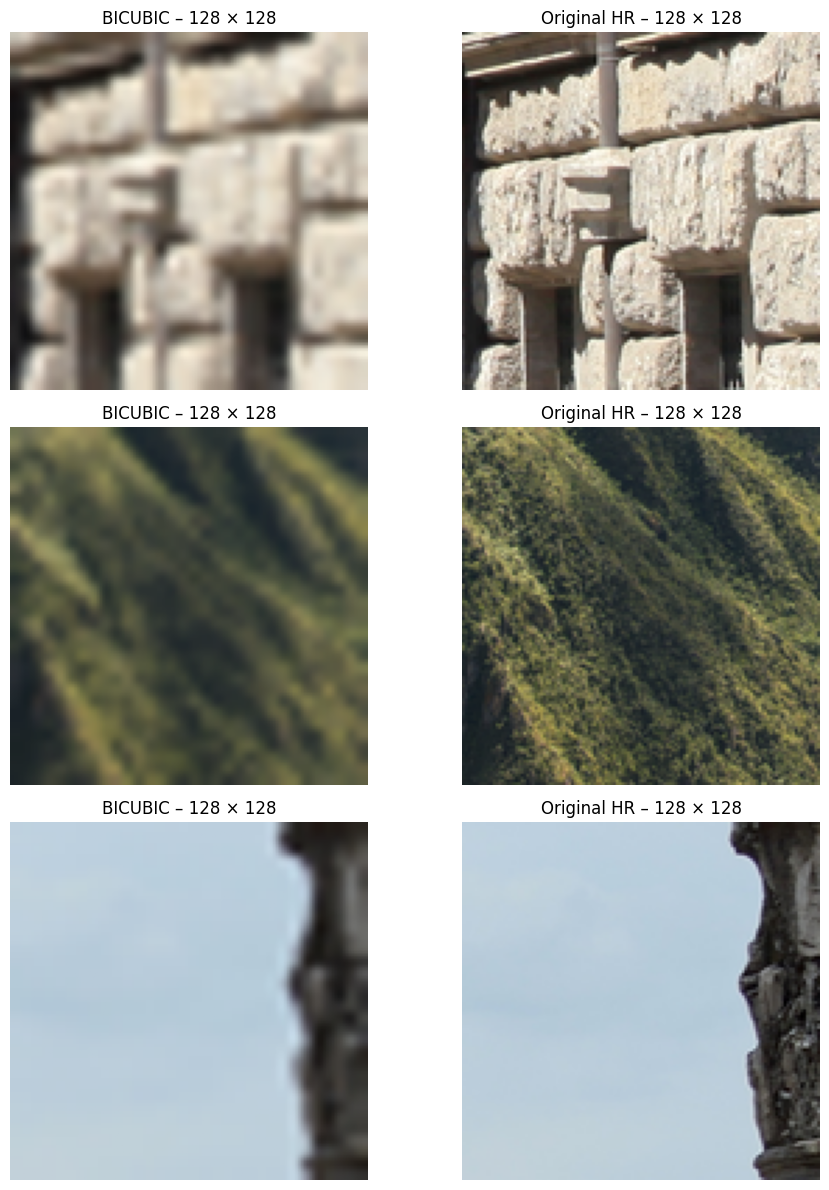

In [31]:
import random

random_indices = random.sample(range(len(X_train_upscaled)), 3)

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for i, idx in enumerate(random_indices):

    axes[i, 0].imshow(X_train_upscaled[idx])
    axes[i, 0].set_title("BICUBIC – 128 × 128")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(y_train[idx])
    axes[i, 1].set_title("Original HR – 128 × 128")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

<small>

> Vizuelnim poređenjem BICUBIC interpoliranih i originalnih HR slika provereno je da li je proces upsamplinga pravilno izvršen. <br>
>**BICUBIC slike** imaju **istu rezoluciju** kao **HR slike**, ali sadrže **manje detalja**, koje će **SRCNN** pokušati da **rekonstruiše**.

</small>

#### V : Konverzija podataka u tenzore i priprema za treniranje

<small>

Nakon prethodne obrade, podaci se pripremaju za unos u **SRCNN model** implementiran u PyTorch-u.

- **Prilagođavanje formata**: LR i HR slike se **transponuju** iz formata $(H, W, C)$ u $(C, H, W)$, jer PyTorch **konvolutivni slojevi** očekuju da se **broj kanala** nalazi **pre dimenzija slike**.
- **Konverzija u tenzore**: $NumPy$ nizovi se pretvaraju u $torch.Tensor$ objekte kako bi mogli direktno da se koriste u PyTorch modelu.
- **Formiranje skupova**: Odvojeno se formiraju $train_dataset$ i $val_dataset$, koji sadrže **ulazne BICUBIC slike** i odgovarajuće **originalne HR slike**.
- **Batch obrada**: Podaci se organizuju u **batch**-eve od $16$ slika, čime se omogućava **istovremena obrada** više uzoraka tokom treniranja.
- **Mešanje podataka**: Trening podaci se nasumično mešaju ($shuffle=True$) kako bi se **smanjila zavisnost modela** od **redosleda uzoraka**, dok se kod validacionog skupa redosled zadržava ($shuffle=False$) radi konzistentne evaluacije.

</small>

In [32]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_upscaled = np.transpose(X_train_upscaled, (0, 3, 1, 2))
y_train = np.transpose(y_train, (0, 3, 1, 2))

X_val_upscaled = np.transpose(X_val_upscaled, (0, 3, 1, 2))
y_val = np.transpose(y_val, (0, 3, 1, 2))

print("X_train_upscaled:", X_train_upscaled.shape)
print("y_train:", y_train.shape)

X_train_tensor = torch.tensor(X_train_upscaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_upscaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

X_train_upscaled: (8000, 3, 128, 128)
y_train: (8000, 3, 128, 128)


<small>

> Nakon transponovanja, **trening podaci** imaju oblik $(8000, 3, 128, 128)$, što odgovara $PyTorch$ formatu (**broj slika**, **broj kanala**, **visina**, **širina**). <br>
> Time su **BICUBIC** i **originalne HR** slike **usklađene po dimenzijama** i spremne za unos u **SRCNN model**.

</small>

#### VI : Arhitektura SRCNN mreže

<small>

U ovom koraku definisana je **SRCNN** (*Super-Resolution Convolutional Neural Network*) mreža koja služi kao **baseline model** za **rekonstrukciju HR slika**.

- Cilj modela je da iz **BICUBIC interpolirane slike** dimenzija $128×128$ nauči da **rekonstruiše detalje** i približi je **originalnoj HR slici**.
- Arhitektura je namerno **jednostavna** i sastoji se od **tri konvolutivna sloja**, što omogućava da se proceni koliko **osnovna CNN arhitektura** može da **poboljša BICUBIC interpolirane slike**.
</small>

<small>

- **Prvi sloj**: $3 → 64$ **filtera** veličine $9×9$ – služi za izdvajanje **osnovnih karakteristika** iz **RGB slike** i koristi **veći kernel** kako bi obuhvatio **širi lokalni deo** slike. <br>
- **Drugi sloj**: $64 → 32$ **filtera** veličine $5×5$ – obrađuje **prethodno izdvojene karakteristike** i uči **složenije obrasce**. Nakon prvog i drugog sloja koristi se **ReLU aktivaciona funkcija**. <br>
- **Treći sloj**: $32 → 3$ **filtera** veličine $5×5$ – **rekonstruiše konačnu RGB sliku**.<br>

</small>

<small>

- **Padding** je podešen tako da se **dimenzije slike** tokom prolaska kroz mrežu **ne menjaju**, pa model na **izlazu** dobija sliku dimenzija $128×128×3$, kao i **ciljna HR slika**.
- Ovakva jednostavna tro-slojna arhitektura izabrana je kao **baseline**, kako bi se dobila početna **procena kvaliteta super-rezolucije** i kasnije omogućilo poređenje sa složenijim modelima.

</small>

In [34]:
import torch.nn as nn
import torch.nn.functional as F

class SRCNN(nn.Module):

    def __init__(self):

        super(SRCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=9, padding=4)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=32, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=3, kernel_size=5, padding=2)

    def forward(self, x):

        x = self.conv1(x)
        x = F.relu(x)

        x = self.conv2(x)
        x = F.relu(x)

        x = self.conv3(x)

        return x

model = SRCNN()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

SRCNN(
  (conv1): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (conv2): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv3): Conv2d(32, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)

<small>

> Kreirana je instanca **SRCNN modela** i određen je **uređaj za izvršavanje** modela. <br>
> Ukoliko je GPU dostupan, koristiće se CUDA, a u suprotnom model će se izvršavati na CPU-u. 

</small>

#### VII : Treniranje SRCNN modela

<small>

- Kao funkcija gubitka (*loss*) korišćena je **srednja kvadratna greška** (*MSE*) između predviđene i ciljne (visoko-rezolucijske) slike, jer direktno penalizuje **odstupanje intenziteta piksela** i standardna je funkcija gubitka za regresione probleme rekonstrukcije slika poput super-rezolucije.
- Uporedo sa **MSE**, tokom treninga je praćena i **srednja apsolutna greška** (*MAE*) kao dodatna, robusnija metrika koja **manje penalizuje ekstremna odstupanja** (*outliere*) i daje dodatni uvid u ponašanje modela.

</small>

In [ ]:
import torch
import torch.optim as optim
import torch.nn.functional as F
import copy
from torchmetrics.image import StructuralSimilarityIndexMeasure, PeakSignalNoiseRatio

optimizer = optim.Adam(model.parameters(), lr = 0.001, weight_decay=1e-4)
n_epochs = 30

metrics = {'train_mse': [], 'train_mae': [], 'train_step': [], 'val_mse': [], 'val_mae': [], 'val_psnr': [], 'val_ssim': [],'val_step': []}
training_step = 0

ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)

best_val_loss = float("inf")
best_model_state = None
counter = 0
patience = 5

for epoch in range(n_epochs):

    model.train()

    for x_batch, y_batch in train_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        y_pred = model(x_batch)

        mse = F.mse_loss(y_pred, y_batch)
        mae = torch.abs(y_pred - y_batch).mean()

        metrics['train_mse'].append(mse.item())
        metrics['train_mae'].append(mae.item())
        metrics['train_step'].append(training_step)
        training_step += 1

        optimizer.zero_grad()
        mse.backward()
        optimizer.step()

    model.eval()

    val_mse_sum = 0.0
    val_mae_sum = 0.0
    val_samples = 0

    ssim_metric.reset()
    psnr_metric.reset()

    with torch.no_grad():

        for x_batch, y_batch in val_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(x_batch)

            val_mse_sum += F.mse_loss(y_pred, y_batch, reduction='sum').item()
            val_mae_sum += torch.abs(y_pred - y_batch).sum().item()
            val_samples += y_batch.numel()

            # torchmetrics interno akumulira stanje kroz sve batch-eve
            ssim_metric.update(y_pred, y_batch)
            psnr_metric.update(y_pred, y_batch)

    val_mse = val_mse_sum / val_samples
    val_mae = val_mae_sum / val_samples
    val_psnr = psnr_metric.compute().item()
    val_ssim = ssim_metric.compute().item()

    metrics['val_mse'].append(val_mse)
    metrics['val_mae'].append(val_mae)
    metrics['val_psnr'].append(val_psnr)
    metrics['val_ssim'].append(val_ssim)
    metrics['val_step'].append(training_step)


    print(f"Epoch {epoch+1}/{n_epochs}, " f"Val MSE: {val_mse:.6f}, "f"Val MAE: {val_mae:.6f}, "f"Val PSNR: {val_psnr:.2f} dB, " f"Val SSIM: {val_ssim:.4f}")

    if val_mse + 1e-5 < best_val_loss:
        best_val_loss = val_mse
        best_model_state = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("EARLY STOPPING!")
            break

Epoch 1/30, Val MSE: 0.003423, Val MAE: 0.032717, Val PSNR: 24.66 dB, Val SSIM: 0.7372
Epoch 2/30, Val MSE: 0.003435, Val MAE: 0.032751, Val PSNR: 24.64 dB, Val SSIM: 0.7318
Epoch 3/30, Val MSE: 0.003344, Val MAE: 0.032256, Val PSNR: 24.76 dB, Val SSIM: 0.7409
Epoch 4/30, Val MSE: 0.003287, Val MAE: 0.031786, Val PSNR: 24.83 dB, Val SSIM: 0.7456


In [ ]:
y_train.shape

(8000, 128, 128, 3)

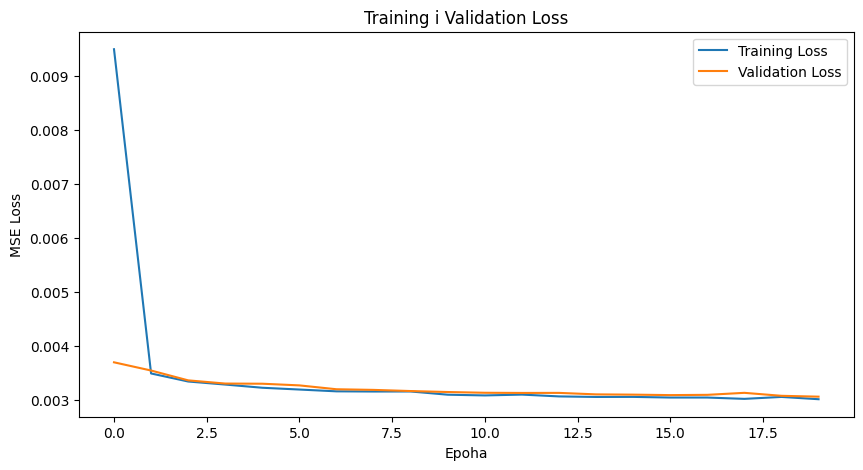

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoha")
plt.ylabel("MSE Loss")
plt.title("Training i Validation Loss")
plt.legend()
plt.show()

In [31]:
model.eval()

predictions = []

with torch.no_grad():
    for inputs, _ in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        predictions.append(outputs.cpu().numpy())

predictions = np.concatenate(predictions, axis=0)

print("Predictions:", predictions.shape)

Predictions: (1000, 3, 128, 128)


In [ ]:
predictions = np.transpose(predictions, (0, 2, 3, 1))
y_val_eval = np.transpose(y_val, (0, 2, 3, 1))
X_val_eval = np.transpose(X_val_upscaled, (0, 2, 3, 1))

predictions = np.clip(predictions, 0, 1)

In [33]:
from skimage.metrics import peak_signal_noise_ratio

psnr_values = []

for i in range(len(y_val_eval)):
    score = peak_signal_noise_ratio(
        y_val_eval[i],
        predictions[i],
        data_range=1.0
    )
    
    psnr_values.append(score)

mean_psnr = np.mean(psnr_values)

print(f"Prosečan PSNR: {mean_psnr:.4f} dB")

Prosečan PSNR: 29.8144 dB


In [34]:
from skimage.metrics import structural_similarity

ssim_values = []

for i in range(len(y_val_eval)):
    score = structural_similarity(
        y_val_eval[i],
        predictions[i],
        data_range=1.0,
        channel_axis=-1
    )
    
    ssim_values.append(score)

mean_ssim = np.mean(ssim_values)

print(f"Prosečan SSIM: {mean_ssim:.4f}")

Prosečan SSIM: 0.7795


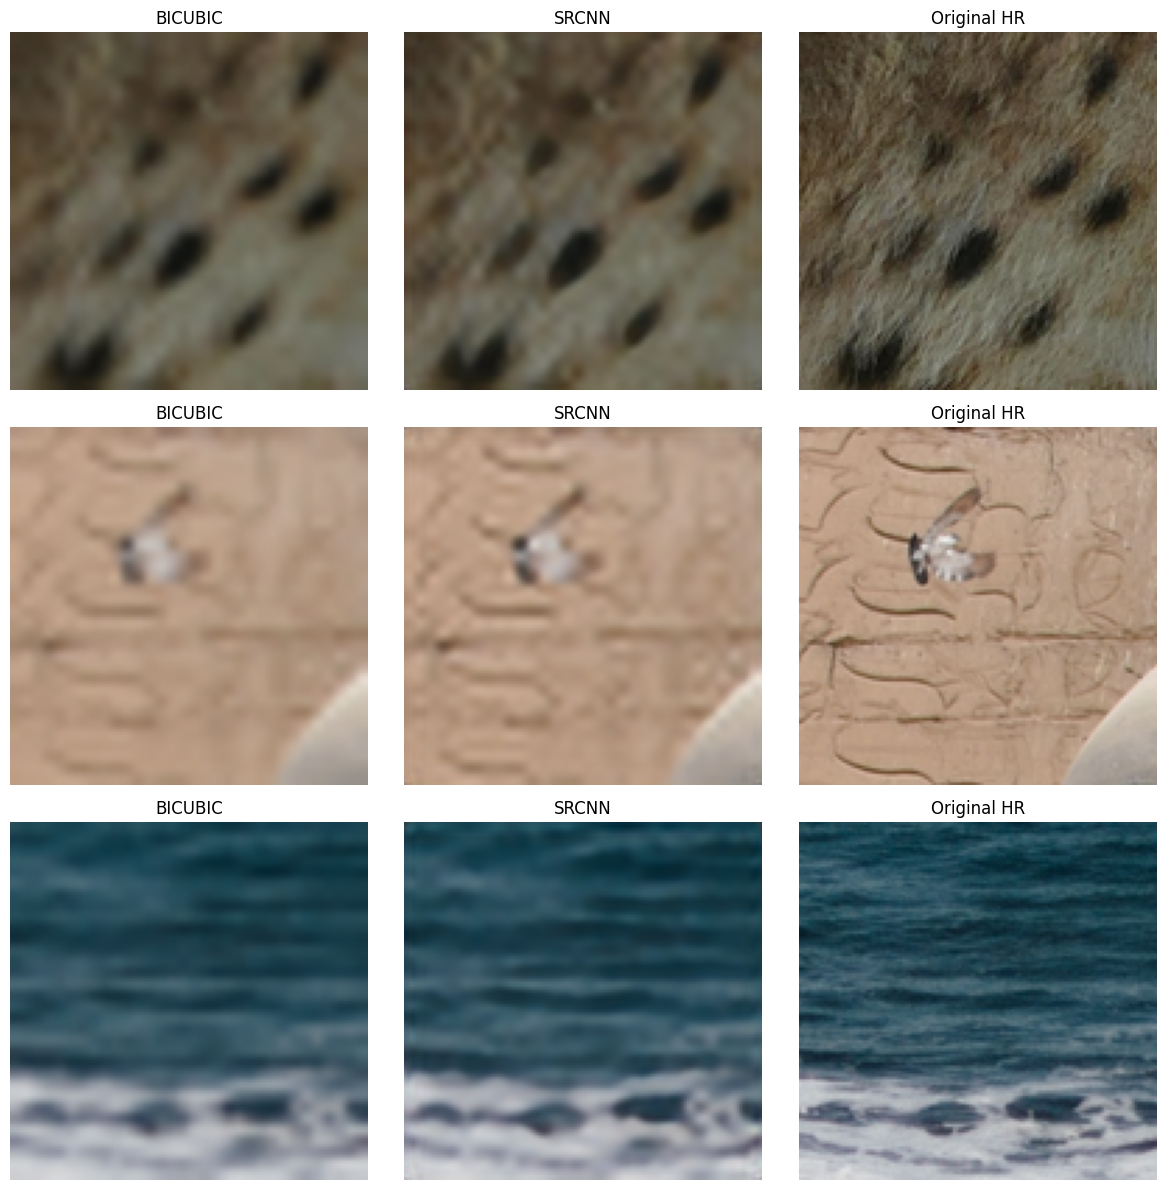

In [35]:
import random

random_indices = random.sample(range(len(y_val_eval)), 3)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i, idx in enumerate(random_indices):

    axes[i, 0].imshow(X_val_eval[idx])
    axes[i, 0].set_title("BICUBIC")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(predictions[idx])
    axes[i, 1].set_title("SRCNN")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(y_val_eval[idx])
    axes[i, 2].set_title("Original HR")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [36]:
bicubic_psnr = []
bicubic_ssim = []

for i in range(len(y_val_eval)):

    bicubic_psnr.append(
        peak_signal_noise_ratio(
            y_val_eval[i],
            X_val_eval[i],
            data_range=1.0
        )
    )

    bicubic_ssim.append(
        structural_similarity(
            y_val_eval[i],
            X_val_eval[i],
            data_range=1.0,
            channel_axis=-1
        )
    )

print(f"BICUBIC PSNR: {np.mean(bicubic_psnr):.4f} dB")
print(f"SRCNN PSNR:   {mean_psnr:.4f} dB")

print(f"BICUBIC SSIM: {np.mean(bicubic_ssim):.4f}")
print(f"SRCNN SSIM:   {mean_ssim:.4f}")

C:\Users\T590\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\skimage\metrics\simple_metrics.py:171: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


BICUBIC PSNR: inf dB
SRCNN PSNR:   29.8144 dB
BICUBIC SSIM: 0.7545
SRCNN SSIM:   0.7795


In [37]:
bicubic_psnr_mean = np.mean(bicubic_psnr)
bicubic_ssim_mean = np.mean(bicubic_ssim)

print(f"BICUBIC PSNR: {bicubic_psnr_mean:.4f} dB")
print(f"SRCNN PSNR:   {mean_psnr:.4f} dB")

print(f"BICUBIC SSIM: {bicubic_ssim_mean:.4f}")
print(f"SRCNN SSIM:   {mean_ssim:.4f}")

print("\n--- POBOLJŠANJE ---")

print(f"PSNR poboljšanje: {mean_psnr - bicubic_psnr_mean:.4f} dB")
print(f"SSIM poboljšanje: {mean_ssim - bicubic_ssim_mean:.4f}")

BICUBIC PSNR: inf dB
SRCNN PSNR:   29.8144 dB
BICUBIC SSIM: 0.7545
SRCNN SSIM:   0.7795

--- POBOLJŠANJE ---
PSNR poboljšanje: -inf dB
SSIM poboljšanje: 0.0251
